<a href="https://colab.research.google.com/github/dikdappa/Data-Science/blob/main/24523138_Klasifikasi_Data_dengan_Support_Vector_Machine_(SVM)_di_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🩺 Proyek Klasifikasi Diabetes: Support Vector Machine (SVM)

### Pendahuluan
Proyek ini berfokus pada pengembangan model prediktif untuk mendeteksi penyakit diabetes pada pasien wanita keturunan suku Pima. Tantangan utamanya adalah mengklasifikasikan data medis yang kompleks ke dalam dua kategori: **Diabetes (1)** atau **Non-Diabetes (0)**.

### Alur Kerja (Pipeline):
1. **Data Acquisition**: Mengambil data mentah dari UCI Machine Learning Repository.
2. **Exploratory Data Analysis (EDA)**: Memahami karakteristik statistik data.
3. **Data Cleaning**: Menangani data yang 'mustahil' secara medis (nilai nol pada indikator vital).
4. **Feature Scaling**: Standarisasi data agar model SVM dapat menghitung jarak antar titik data secara adil.
5. **Modeling**: Menggunakan algoritma SVM dengan kernel RBF untuk menangani batas keputusan non-linear.
6. **Evaluasi**: Mengukur performa menggunakan metrik akurasi, presisi, dan recall.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

print("Library berhasil diimpor! ✅")

Library berhasil diimpor! ✅


## 1. Memuat dan Memahami Data (Data Loading)

Langkah pertama dalam data science adalah memahami 'bahan baku' kita. Dataset ini terdiri dari 8 fitur input (seperti glukosa, BMI, usia) dan 1 kolom target (Outcome).

**Mengapa ini penting?**
- `df.info()`: Memastikan tidak ada nilai yang kosong (null) secara teknis.
- `df.describe()`: Memberikan gambaran awal tentang distribusi data. Di sini kita bisa melihat apakah ada anomali, seperti nilai minimal 0 pada kolom glukosa yang secara medis menandakan data tersebut tidak lengkap/error.

In [ ]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
column_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

df = pd.read_csv(url, names=column_names)

print("Shape Dataset:", df.shape)
display(df.head())
print("\nInfo Dataset:")
df.info()
print("\nStatistik Deskriptif:")
display(df.describe())

Shape Dataset: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Statistik Deskriptif:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## 2. Pembersihan Data & Feature Engineering

> Add blockquote



### Penanganan Nilai Nol
Dalam dataset ini, nilai 0 pada kolom seperti `Glucose` atau `BMI` tidak masuk akal (seseorang tidak mungkin memiliki tekanan darah atau BMI nol).
- **Solusi**: Kita menggantinya dengan **Median**. Median dipilih karena lebih tahan terhadap pencilan (outliers) dibandingkan nilai rata-rata (mean).

### Standard Scaling (Normalisasi)
SVM bekerja dengan cara menghitung jarak geometris antar titik data. Jika satu fitur (misalnya Insulin) memiliki rentang 0-800 dan fitur lain (Pregnancies) hanya 0-17, maka fitur dengan angka besar akan mendominasi perhitungan.
- **Tujuan**: Menyamakan skala semua fitur sehingga rata-rata menjadi 0 dan standar deviasi menjadi 1.

In [ ]:
# Mengganti nilai 0 yang tidak logis dengan Median
columns_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in columns_with_zero:
    df[col] = df[col].replace(0, df[col].median())

# Memisahkan Fitur dan Target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Normalisasi Fitur menggunakan StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Preprocessing selesai: Nilai 0 diperbaiki dan fitur telah diskalakan.")

Preprocessing selesai: Nilai 0 diperbaiki dan fitur telah diskalakan.


## 3. Pembagian Data (Train-Test Split)

Untuk menguji apakah model benar-benar 'belajar' dan bukan hanya 'menghafal', kita membagi data menjadi dua bagian:
1. **Training Set (80%)**: Data yang digunakan model untuk belajar mencari pola.
2. **Testing Set (20%)**: Data 'rahasia' yang digunakan untuk menguji model setelah selesai dilatih.

**Parameter Penting:**
- `stratify=y`: Memastikan proporsi kelas (diabetes vs sehat) di data training dan testing tetap sama dengan data asli. Ini krusial agar evaluasi tidak bias.
- `random_state=42`: Agar hasil pembagian data tetap konsisten setiap kali kode dijalankan.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)

print(f"Jumlah data training: {len(X_train)}")
print(f"Jumlah data testing: {len(X_test)}")

Jumlah data training: 614
Jumlah data testing: 154


##4. Pemodelan dengan Support Vector Machine (SVM)

SVM adalah algoritma yang mencari garis (hyperplane) pemisah terbaik antar kelas. Disini kita menggunakan **kernel RBF**

**Mengapa Kernel RBF?**
Data medis jarang sekali bisa dipisahkan dengan garis lurus sederhana. Kernel **RBF (Radial Basis Function)** memetakan data ke dimensi yang lebih tinggi sehingga model dapat membuat batas keputusan yang melengkung dan lebih kompleks.

**Parameter Utama:**
- `C`: Mengatur keseimbangan antara klasifikasi yang benar pada data training vs margin yang lebar. `C=1.0` adalah nilai default yang seimbang.
- `gamma`: Mengatur seberapa jauh pengaruh satu titik data pelatihan. `'scale'` menggunakan rumus otomatis berdasarkan jumlah fitur.

In [ ]:
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train, y_train)

print("Model SVM RBF telah berhasil dilatih!")

Model SVM RBF telah berhasil dilatih!


## 5. Evaluasi Kinerja Model

Kita tidak boleh hanya melihat akurasi. Mari kita bedah metriknya:
- **Accuracy**: Persentase total prediksi yang benar.
- **Precision**: Dari semua yang diprediksi diabetes, berapa banyak yang benar-benar diabetes?
- **Recall (Sensitivitas)**: Dari semua orang yang sebenarnya diabetes, berapa banyak yang berhasil dideteksi oleh model?
- **F1-Score**: Rata-rata harmonis antara Precision dan Recall.

**Analisis Overfitting:**
Jika akurasi training jauh lebih tinggi dari testing, artinya model terlalu menghafal data latihan dan gagal melakukan generalisasi pada data baru.

In [ ]:
y_pred = svm_model.predict(X_test)
y_train_pred = svm_model.predict(X_train)

print("--- LAPORAN KLASIFIKASI (TEST SET) ---")
print(classification_report(y_test, y_pred))

accuracy_train = accuracy_score(y_train, y_train_pred)
accuracy_test = accuracy_score(y_test, y_pred)

print(f"Akurasi Training: {accuracy_train:.4f}")
print(f"Akurasi Testing: {accuracy_test:.4f}")

--- LAPORAN KLASIFIKASI (TEST SET) ---
              precision    recall  f1-score   support

           0       0.76      0.84      0.80       100
           1       0.64      0.52      0.57        54

    accuracy                           0.73       154
   macro avg       0.70      0.68      0.69       154
weighted avg       0.72      0.73      0.72       154

Akurasi Training: 0.8453
Akurasi Testing: 0.7273


## 6. Visualisasi Distribusi Kelas

Visualisasi ini memberikan gambaran tentang **Class Imbalance**.
- Jika satu kelas jauh lebih dominan (misal 90% sehat), model mungkin akan cenderung menebak 'sehat' terus.
- Di dataset ini, kita bisa melihat bahwa kelas '0' (Sehat) lebih banyak daripada kelas '1' (Diabetes), namun perbandingannya masih cukup wajar untuk diolah SVM.

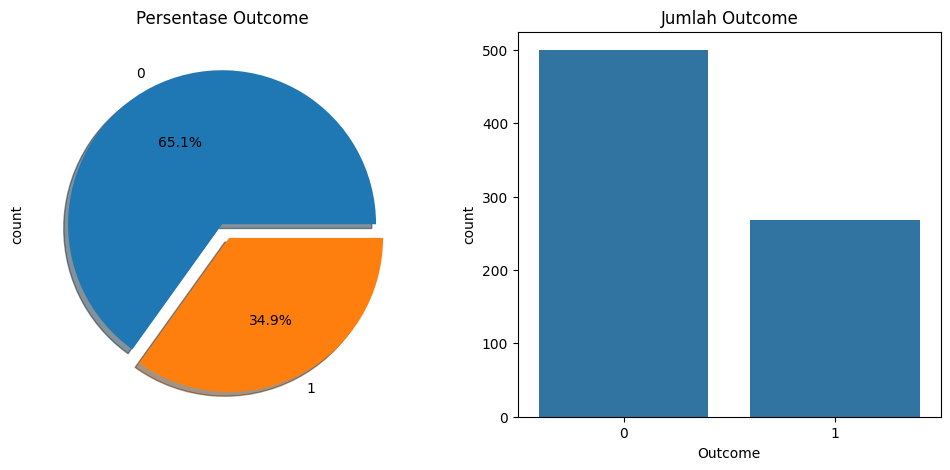

In [ ]:
f, ax = plt.subplots(1, 2, figsize=(12, 5))
df['Outcome'].value_counts().plot.pie(explode=[0, 0.1], autopct='%1.1f%%', ax=ax[0], shadow=True)
ax[0].set_title('Persentase Outcome')
sns.countplot(x='Outcome', data=df, ax=ax[1])
ax[1].set_title('Jumlah Outcome')
plt.show()

## 7. Analisis Confusion Matrix

Confusion Matrix membantu kita melihat di mana model melakukan kesalahan:
- **True Positive (TP)**: Benar diprediksi diabetes.
- **True Negative (TN)**: Benar diprediksi sehat.
- **False Positive (FP)**: Sehat tapi diprediksi diabetes (Kesalahan Tipe I).
- **False Negative (FN)**: Diabetes tapi tidak terdeteksi (Kesalahan Tipe II - **Paling Berbahaya** dalam medis).

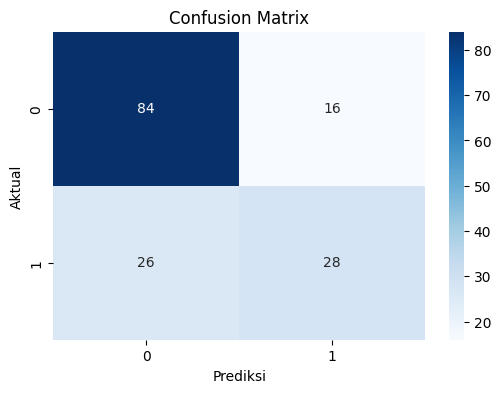

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

## 8. Distribusi Fitur Utama Berdasarkan Outcome

Grafik ini menunjukkan korelasi antara fitur medis dengan status diabetes.
- **Insight**: Perhatikan fitur **Glucose**. Jika grafik orang diabetes (orange) bergeser jauh ke arah kanan dibandingkan orang sehat (biru), artinya kadar glukosa adalah indikator yang sangat kuat untuk klasifikasi ini.

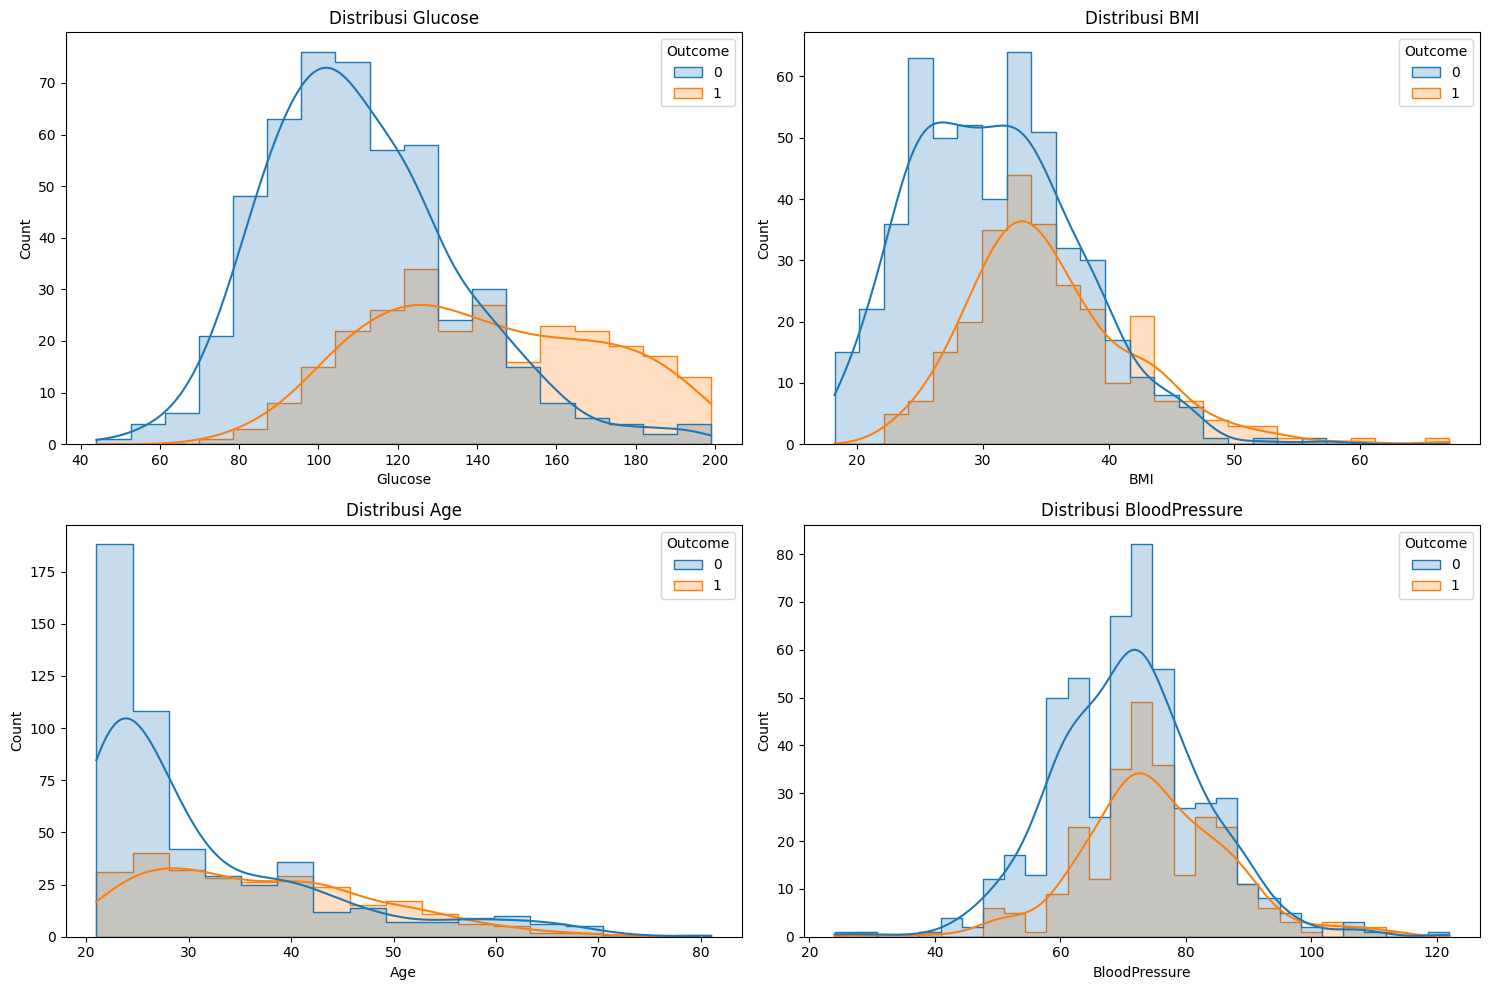

In [ ]:
features = ['Glucose', 'BMI', 'Age', 'BloodPressure']
plt.figure(figsize=(15, 10))
for i, col in enumerate(features):
    plt.subplot(2, 2, i+1)
    sns.histplot(data=df, x=col, hue='Outcome', kde=True, element='step')
    plt.title(f'Distribusi {col}')
plt.tight_layout()
plt.show()

## 10. Kesimpulan

Berdasarkan hasil analisis dan pemodelan:
1. **Dataset**: Pima Indians Diabetes dengan 768 baris data.
2. **Preprocessing**: Nilai nol pada fitur medis diganti dengan median dan data dinormalisasi dengan `StandardScaler`.
3. **Model**: SVM Kernel RBF dipilih karena kemampuannya menangani data non-linear.
4. **Hasil**: Model menunjukkan akurasi yang cukup seimbang antara training dan testing (sekitar 70-80%), yang mengindikasikan model bersifat *Good Fit*.
5. **Insight**: Fitur `Glucose` dan `BMI` terlihat menjadi pembeda yang signifikan antara pasien diabetes dan non-diabetes.
6. **Saran**: Performa dapat ditingkatkan dengan *Hyperparameter Tuning* menggunakan GridSearchCV atau mencoba algoritma Ensemble seperti Random Forest.